In [1]:
import mesa_reader as mr
import numpy as np
import matplotlib.pyplot as plt
import os
import astropy.units as u

In [2]:
dir = "./saved_files"
files = [os.path.join(dir, f) for f in os.listdir(dir)]

plt.style.use("~/Documents/mplstyles/presentation.mplstyle")

Duplicate key in file '~/Documents/mplstyles/presentation.mplstyle', line 10 ('axes.labelsize : 24')


In [3]:
# masses1 = np.linspace(0.03, 0.09, num=8)
masses2 = np.linspace(0.1, 0.9, num=10)
masses3 = np.linspace(1, 20, num=20)
# masses = np.concatenate((masses1, masses2, masses3))
masses = np.concatenate((masses2, masses3))

base_ages = np.array([25, 100, 250, 500, 980, 990, 1000, 2500, 5000, 10000]) * u.Myr
base_ages = np.array([25, 100, 250, 500, 1000, 2500, 5000, 10000]) * u.Myr
ages = base_ages.to(u.yr).value
log_Ls = np.zeros((len(masses), len(ages)))
log_Teffs = np.zeros((len(masses), len(ages)))

for mass in masses:
    if mass < 0.1:
        MS_fname = os.path.join(dir, f"MS_{mass:.2f}_Msun.data")
        PMS_fname = os.path.join(dir, f"PMS_{mass:.2f}_Msun.data")
    else:
        MS_fname = os.path.join(dir, f"MS_{mass:.1f}_Msun.data")
        PMS_fname = os.path.join(dir, f"PMS_{mass:.1f}_Msun.data")

    ms = mr.MesaData(MS_fname)
    pms = mr.MesaData(PMS_fname)

    star_age = np.concatenate((ms.star_age, pms.star_age))
    log_L = np.concatenate((ms.log_L, pms.log_L))
    log_Teff = np.concatenate((ms.log_Teff, pms.log_Teff))

    temp_idxs = np.zeros_like(ages, dtype=int)
    for i, age in enumerate(ages):
        age_idx = np.argmin(np.abs(star_age - age))
        temp_idxs[i] = age_idx
        # print(age_idx)
    log_Ls[masses == mass] = log_L[temp_idxs]
    log_Teffs[masses == mass] = log_Teff[temp_idxs]

/var/folders/6l/y2z2vm4913sb2lzhwp95z6q00000gn/T/ipykernel_20772/402017116.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


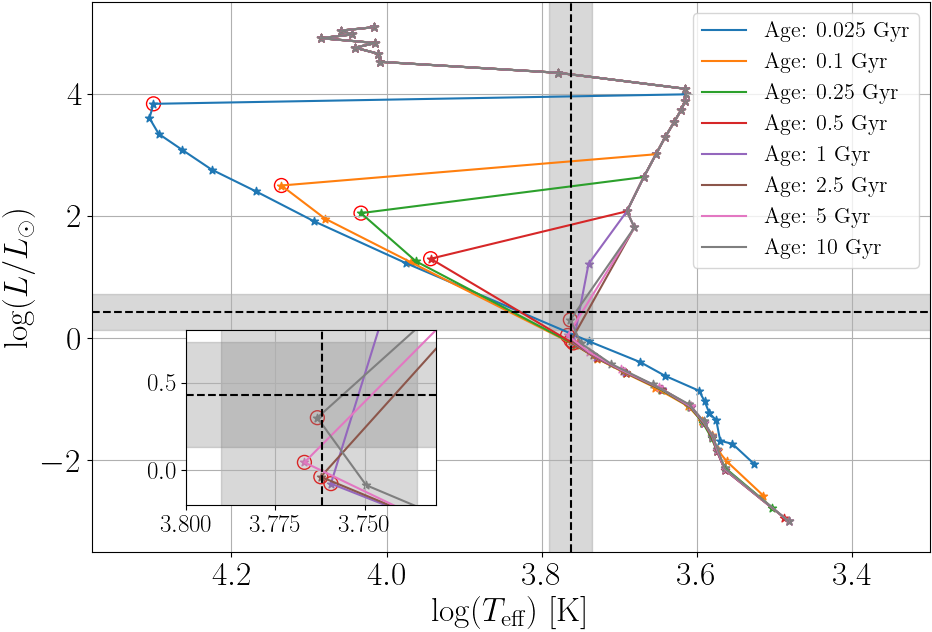

[2.5e+07 1.0e+08 2.5e+08 5.0e+08 1.0e+09 2.5e+09 5.0e+09 1.0e+10]
[9. 4. 3. 2. 1. 1. 1. 1.]


In [47]:
turn_offs = np.array([18, 13, 12, 11, 11, 11, 10, 10, 10, 9])
turn_offs = np.array([18, 13, 12, 11, 10, 10, 10, 10])
fig = plt.figure(figsize=(10,7))

for i in range(len(ages)):
    plt.plot(log_Teffs[:, i], log_Ls[:, i], label=f"Age: {base_ages[i].to(u.Gyr):n}")
    plt.scatter(log_Teffs[:, i], log_Ls[:, i], marker='*')
    plt.scatter(log_Teffs[turn_offs[i], i], log_Ls[turn_offs[i], i], edgecolors='red', facecolors='none', marker='o', s=100)
    plt.legend()
plt.xlabel(r"$\log(T_{\rm eff})$ [K]")
plt.ylabel(r"$\log(L/L_{\odot})$")
plt.xlim(4.38, 3.3)

plt.axvline(x=3.7618, color='k', linestyle='--')
plt.axhline(y=0.43, color='k', linestyle='--')
plt.fill_betweenx(y=[-4, 6], x1=3.7903, x2=3.7353, color='gray', alpha=0.3)
plt.fill_between(x=[5, 3], y1=0.13, y2=0.73, color='gray', alpha=0.3)

plt.ylim(-3.5, 5.5)
plt.grid()

# add an inset plot that plots the same thing but is zoomed in on a region
ax_inset = fig.add_axes([0.22, 0.23, 0.25, 0.25])
for i in range(len(ages)):
    if i < 4:
        plt.plot(0,0)
        plt.scatter(0,0)
        continue
    ax_inset.plot(log_Teffs[:, i], log_Ls[:, i], label=f"Age: {base_ages[i].to(u.Gyr):n}")
    ax_inset.scatter(log_Teffs[:, i], log_Ls[:, i], marker='*')
    ax_inset.scatter(log_Teffs[turn_offs[i], i], log_Ls[turn_offs[i], i], edgecolors='red', facecolors='none', marker='o', s=100)
# set tick size for inset
ax_inset.tick_params(axis='both', which='major', labelsize=18)
ax_inset.axvline(x=3.7618, color='k', linestyle='--')
ax_inset.axhline(y=0.43, color='k', linestyle='--')
plt.fill_betweenx(y=[-4, 6], x1=3.7903, x2=3.7353, color='gray', alpha=0.3)
plt.fill_between(x=[5, 3], y1=0.13, y2=0.73, color='gray', alpha=0.3)
ax_inset.set_ylim(-0.2, 0.8)
ax_inset.set_xlim(3.8, 3.73)

ax_inset.grid()

plt.tight_layout()
plt.savefig("isochrones.png", dpi=300, bbox_inches='tight')
plt.show()

print(ages)
print(masses[turn_offs])

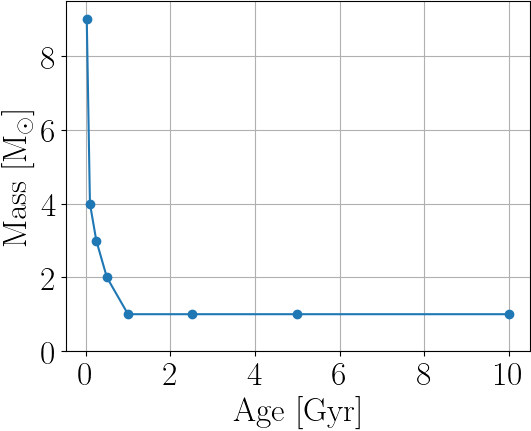

In [43]:
fig = plt.figure(figsize=(6,5))
plt.plot(base_ages.to(u.Gyr).value, masses[turn_offs], marker='o')
plt.xlabel("Age [Gyr]")
plt.ylabel(r"Mass [M$_\odot$]")
plt.xticks(ticks=np.arange(0, 11, 2))
plt.ylim(0, 9.5)
plt.grid()
plt.tight_layout()
plt.savefig("mass_vs_age.png", dpi=300, bbox_inches='tight')
plt.show()